# An Simulation Study of the Effectiveness of Causal Forest using Python
---

2025-5-22

Zhiyuan Chen 


## Simulation Study 
Our simulation studies focus particularly on scenarios relevant to management research, such as:

- The heterogeneous impact of internationalization strategies across firms with different resource configurations
- Varying effects of corporate governance changes across different institutional environments
- Differential responses to competitive actions based on firm size and market position


This implementation provides:

1. A realistic data generation process that mimics management research scenarios

2. A comprehensive causal forest implementation using the **econml** library
   
3. Visualization tools for interpreting results
Performance evaluation metrics

The simulation specifically addresses common scenarios in management research by:

1. Modeling firm characteristics realistically (size, R&D intensity, market share, etc.)
   
2. Including heterogeneous treatment effects based on firm characteristics
Incorporating realistic noise and confounding factors

The simulation exercise uses the [**econml**]( https://econml.azurewebsites.net/spec/estimation/forest.html?highlight=causal%20forest) python package, also see the user guide for [DMLForest](https://econml.azurewebsites.net/spec/estimation/dml.html#dmluserguide) 



### Setting and Design

To illustrate the application of Causal Forest in a management context, we conducted a simulation study that mimics typical scenarios in management research. The simulation is designed to explore how firm characteristics influence the heterogeneous effects of an intervention, such as an internationalization decision, on firm performance.

#### Econometric Model
The simulated data are generated based on the following model:
$$
Y = \beta_0 + T \cdot \tau(X) + \epsilon,
$$
where $Y $ is the outcome (e.g., firm performance), $T $ is the treatment indicator (1 if the firm decides to internationalize, 0 otherwise), $\tau(X) $ represents the heterogeneous treatment effect, and $\epsilon $ is random noise. The treatment effect $\tau(X) $ is defined as:
$$
\tau(X) = 0.2 \cdot \text{firm\_size} + 0.3 \cdot \text{rd\_intensity} - 0.1 \cdot \text{market\_share} + 0.1 \cdot \text{international\_experience}.
$$


#### Variables and Parameter Values
1. **Firm Size:** Logarithm of the number of employees, generated as a normal random variable with mean 5 and standard deviation 1.5.
   
2. **R&D Intensity:** Ratio of R&D expenditure to revenue, drawn from a Beta(2, 5) distribution.
   
3. **Market Share:** Proportion of market controlled by the firm, drawn from a Beta(2, 8) distribution.
   
4. **Age:** Firm age in years, simulated using a Gamma(10, 2) distribution.


5. **International Experience:** Years of international operations, simulated using a Gamma(5, 2) distribution.


#### Treatment Assignment
The probability of receiving the treatment is determined by a propensity score model:
$$
P(T = 1 | X) = \Phi(0.2 \cdot \text{firm\_size} + 0.5 \cdot \text{international\_experience} + 0.3 \cdot \text{rd\_intensity} - 0.1 \cdot \text{age}),
$$
where $\Phi $ is the cumulative distribution function of the standard normal distribution.

#### Outcome Generation
The observed outcome is given by:
$$
Y = 0.3 \cdot \text{firm\_size} + 0.2 \cdot \text{rd\_intensity} + 0.1 \cdot \text{market\_share} + 0.05 \cdot \text{age} + 0.1 \cdot \text{international\_experience} + T \cdot \tau(X) + \epsilon,
$$
where $\epsilon \sim N(0, 0.5) $ represents random noise.

By incorporating these variables and relationships, the simulation captures realistic dynamics in management studies, such as the interplay between firm characteristics and strategic decisions.









In [35]:
#import relevant packages and modules
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from econml.dml import CausalForestDML
from econml.inference import BootstrapInference
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

In [36]:
#data generation function
def generate_management_data(n_samples=2000, random_state=42):
    """
    Generate synthetic data mimicking management research scenarios
    
    Features:
    - firm_size: log of number of employees
    - rd_intensity: R&D spending / Revenue
    - market_share: market share in primary industry
    - age: firm age in years
    - international_experience: years of international operations
    """
    np.random.seed(random_state)
    
    # Generate features
    firm_size = np.random.normal(5, 1.5, n_samples)  # log scale
    rd_intensity = np.random.beta(2, 5, n_samples)
    market_share = np.random.beta(2, 8, n_samples)
    age = np.random.gamma(10, 2, n_samples)
    international_experience = np.random.gamma(5, 2, n_samples)
    
    # Combine features
    X = np.column_stack([firm_size, rd_intensity, market_share, age, international_experience])
    
    # Generate endogenous treatment (internationalization decision)
    #propensity = norm.cdf(0.2 * firm_size + 0.5 * international_experience + 
      #                   0.3 * rd_intensity - 0.1 * age)
   #T = np.random.binomial(1, propensity)
    # Generate exogenous treatment 
    T = np.random.binomial(1, 0.5, n_samples)

    # Generate heterogeneous treatment effects
    def treatment_effect(x):
        return (0.2 * x[0] +  # larger firms benefit more
                0.3 * x[1] +  # R&D intensive firms benefit more
                -0.1 * x[2] +  # market leaders benefit less
                0.1 * x[4])   # international experience helps
    tau = np.array([treatment_effect(x) for x in X])
    
    # Generate outcome (performance)
    baseline = (0.3 * firm_size + 0.2 * rd_intensity + 0.1 * market_share + 
               0.05 * age + 0.1 * international_experience)
    noise = np.random.normal(0, 0.5, n_samples)
    Y = baseline + tau * T + noise
    
    # Create DataFrame
    feature_names = ['firm_size', 'rd_intensity', 'market_share', 
                    'age', 'international_experience']
    df = pd.DataFrame(X, columns=feature_names)
    df['treatment'] = T
    df['outcome'] = Y
    df['true_effect'] = tau
    
    return df    


In [37]:
#causal forest analysis function 
def run_causal_forest_analysis(df, n_estimators=100):
    """
    Implement causal forest analysis
    """
    # Prepare data
    X = df.drop(['treatment', 'outcome', 'true_effect'], axis=1)
    T = df['treatment']
    Y = df['outcome']
    
    # Split data according to 20-80 rule (20% test, 80% train)
    X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(
        X, T, Y, test_size=0.2, random_state=42)
    
    # Initialize and fit causal forest
    cf = CausalForestDML(
        n_estimators=n_estimators,
        min_samples_leaf=10,
        max_depth=None,
        verbose=0,
        random_state=42
    )
    
    cf.fit(Y_train, T_train, X=X_train)
    
    # Get treatment effects and confidence intervals
    effects = cf.effect(X_test)
    
    # Calculate feature importance
    importance = pd.Series(
        cf.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)
    
    return cf, effects, importance, X_test

In [38]:
# visualization function 
def plot_results(df, effects, X_test, importance):
    """
    Create visualizations for the analysis
    """
    # Plot 1: Predicted vs True Treatment Effects
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    true_effects = df.loc[X_test.index, 'true_effect']
    plt.scatter(true_effects, effects, alpha=0.5)
    plt.plot([min(true_effects), max(true_effects)], 
             [min(true_effects), max(true_effects)], 'r--')
    plt.xlabel('True Treatment Effect')
    plt.ylabel('Predicted Treatment Effect')
    plt.title('Predicted vs True Treatment Effects')
    
    # Plot 2: Feature Importance
    plt.subplot(1, 2, 2)
    importance.plot(kind='bar', color='skyblue', edgecolor='black') 
    #angle of x-axis labels
    plt.xticks(rotation=45)
    plt.title('Feature Importance')
    plt.tight_layout()
    
    return plt


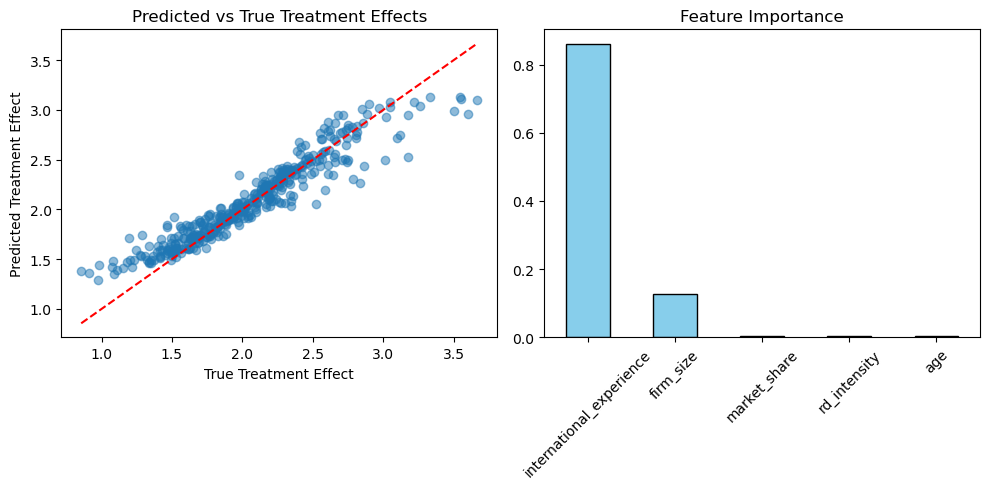


Feature Importance:
international_experience    0.860422
firm_size                   0.128197
market_share                0.004498
rd_intensity                0.003702
age                         0.003181
dtype: float64

Mean Squared Error: 0.0275


In [39]:
# run the program and show the results for different sample size 
    # Generate synthetic data
df = generate_management_data(n_samples=2000)

# Run analysis
cf, effects, importance, X_test = run_causal_forest_analysis(df)

# Create visualizations
plt = plot_results(df, effects, X_test, importance)
plt.show()

# Print summary statistics
print("\nFeature Importance:")
print(importance)

# Calculate performance metrics
true_effects = df.loc[X_test.index, 'true_effect']
mse = np.mean((true_effects - effects) ** 2)
print(f"\nMean Squared Error: {mse:.4f}")


In [ ]:
#Using regression analysis to estimate the mean treatment effects 
# 准备数据
X = df[['treatment']]
X1 = df[['treatment', 'firm_size', 'international_experience', 'rd_intensity', 'age']]
y = df['outcome']
# 添加常数项
X = sm.add_constant(X)
X1 = sm.add_constant(X1) 
# 估计模型
model = sm.OLS(y, X)
model1 = sm.OLS(y, X1)
results = model.fit(cov_type='HC3')
results1 = model1.fit(cov_type='HC3')

In [ ]:
# 保存结果到DataFrame
coef_df = pd.DataFrame({
    'coef': results.params,
    'std_err': results.bse,
    't_stat': results.tvalues,
    'p_value': results.pvalues
})

coef_df1 = pd.DataFrame({
    'coef': results1.params,
    'std_err': results1.bse,
    't_stat': results1.tvalues,
    'p_value': results1.pvalues
})
print("=========================================================================")
print("\n OLS Model 1: No Control Variables")
print("------------------------------------------------------------------------")
print(coef_df)
print("========================================================================")
print("========================================================================")
print("\n OLS Model 2: With Control Variables")
print("------------------------------------------------------------------------")
print(coef_df1)
print("========================================================================")


 OLS Model 1: No Control Variables
------------------------------------------------------------------------
               coef   std_err      t_stat  p_value
const      3.606594  0.027386  131.694776      0.0
treatment  2.064566  0.048754   42.346946      0.0

 OLS Model 2: With Control Variables
------------------------------------------------------------------------
                              coef   std_err     t_stat        p_value
const                    -1.049864  0.079188 -13.257899   4.061128e-40
treatment                 2.097057  0.025495  82.253516   0.000000e+00
firm_size                 0.412716  0.009262  44.562477   0.000000e+00
international_experience  0.145898  0.003349  43.558805   0.000000e+00
rd_intensity              0.361045  0.077643   4.650049   3.318569e-06
age                       0.049365  0.002039  24.211318  1.690792e-129


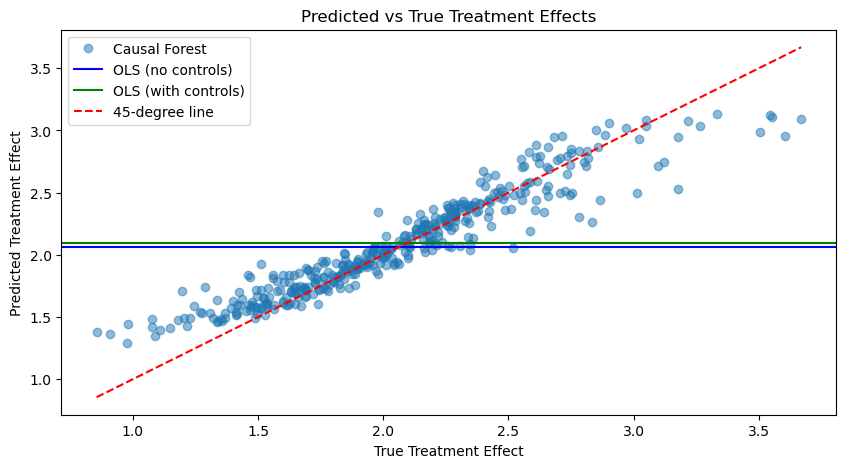

In [50]:
# compare the OLS results and the causal forest results
plt.figure(figsize=(10, 5))
plt.plot(true_effects, effects, 'o', alpha=0.5)
#OLS results as a horizontal line
plt.axhline(results.params.treatment, color='blue', linestyle='-', label='OLS (no controls)')
plt.axhline(results1.params.treatment, color='green', linestyle='-', label='OLS (with controls)')
plt.plot([min(true_effects), max(true_effects)], 
            [min(true_effects), max(true_effects)], 'r--')
plt.xlabel('True Treatment Effect')
plt.ylabel('Predicted Treatment Effect')
plt.legend(labels=['Causal Forest', 'OLS (no controls)', 'OLS (with controls)','45-degree line'])
plt.title('Predicted vs True Treatment Effects')
plt.show()

In [69]:
importance.iloc[0::]

international_experience    0.860422
firm_size                   0.128197
market_share                0.004498
rd_intensity                0.003702
age                         0.003181
dtype: float64

In [83]:
X_test.shape

(400, 5)

In [86]:
# multiply X-test with importance to get a column 
X_value = np.zeros((200, X_test.shape[1]))
X_value[:,0] = np.linspace(X_test['firm_size'].min(), X_test['firm_size'].max(), 200)
X_value[:,1] = X_test['rd_intensity'].mean()
X_value[:,2] = X_test['market_share'].mean()
X_value[:,3] = X_test['age'].mean()
X_value[:,4] = X_test['international_experience'].mean()

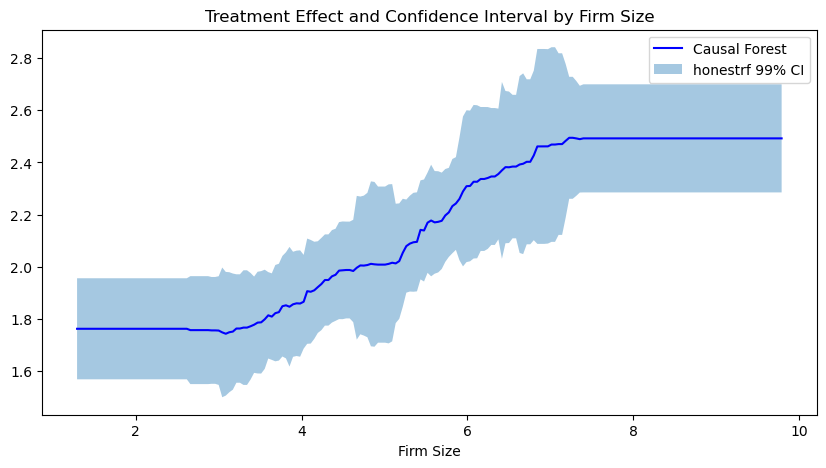

In [92]:
# with honestrf confidence intervals
lb, ub = cf.effect_interval(X_value, alpha=0.01) 
plt.figure(figsize=(10, 5))
plt.plot(X_value[:,0], cf.effect(X_value), color='blue', label='Causal Forest')
plt.fill_between(X_value[:,0], lb, ub, alpha=0.4, label='honestrf 99% CI')
plt.legend()
plt.xlabel('Firm Size')
plt.title('Treatment Effect and Confidence Interval by Firm Size')
plt.show() 